# Project 1: Comparative Study of Bayesian and Non-Parametric Classification
DSCD612 Pattern Recognition, University of Ghana

**Dataset:** UCI Dry Bean Dataset (13,611 observations, 16 morphological features, 7 classes)

This notebook implements and compares a from-scratch multivariate Gaussian Bayesian
classifier against a from-scratch k-NN classifier, following the pattern recognition
pipeline: problem formulation, EDA, feature representation, classifier design,
experimental evaluation, and critical discussion.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pattern_reg.data_loading import load_dry_bean_dataset
from pattern_reg.statistics import compute_mean, compute_covariance, compute_correlation, class_conditional_stats
from pattern_reg.preprocessing import prepare_experiment_data
from pattern_reg.bayesian_classifier import GaussianBayesClassifier
from pattern_reg.knn_classifier import KNNClassifier
from pattern_reg.evaluation import evaluate_predictions
from pattern_reg.visualization import (
    plot_correlation_heatmap, plot_class_distribution, plot_pca_scatter,
    plot_confusion_matrix, plot_accuracy_vs_k,
)

X, y = load_dry_bean_dataset()
print(X.shape, y.shape)
X.head()

(13611, 16) (13611,)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166


## 1. Exploratory Statistical Analysis

Overall mean vector:
 [5.30482845e+04 8.55283459e+02 3.20141867e+02 2.02270714e+02
 1.58324198e+00 7.50894929e-01 5.37682002e+04 2.53064220e+02
 7.49732787e-01 9.87142844e-01 8.73281831e-01 7.99863682e-01
 6.56360851e-03 1.71594733e-03 6.43590181e-01 9.95063312e-01]
Covariance matrix shape: (16, 16)


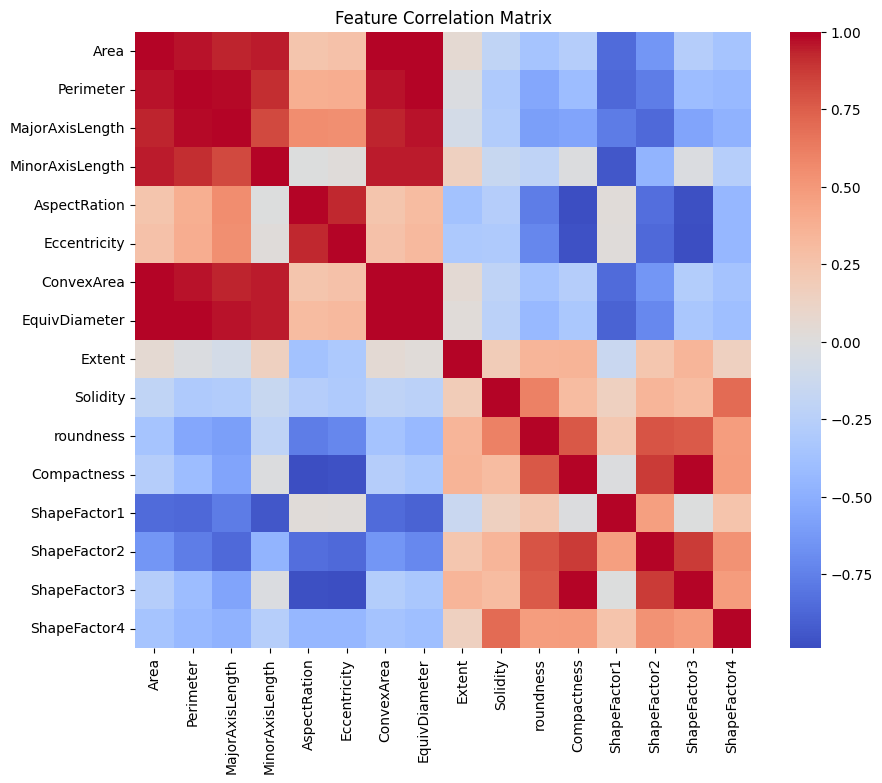

In [2]:
mu = compute_mean(X)
Sigma = compute_covariance(X)
corr = compute_correlation(X)
print("Overall mean vector:\n", mu)
print("Covariance matrix shape:", Sigma.shape)
fig = plot_correlation_heatmap(corr)
fig

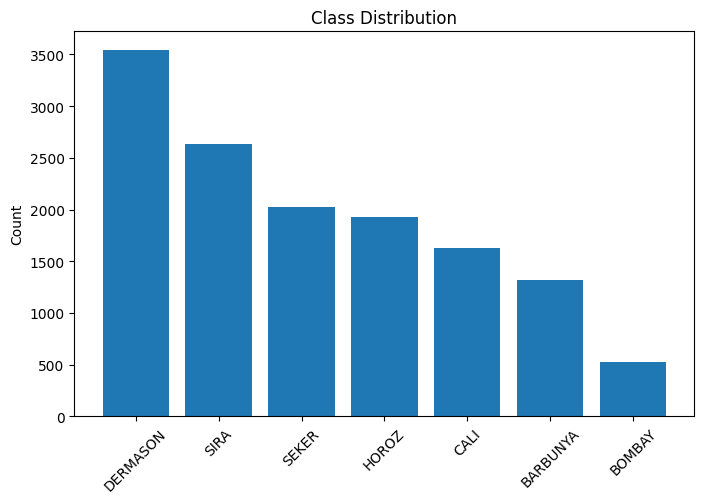

In [3]:
fig = plot_class_distribution(y)
fig

In [4]:
stats = class_conditional_stats(X, y)
for label, s in stats.items():
    print(f"{label}: n={s['n']}, prior={s['prior']:.3f}")

BARBUNYA: n=1322, prior=0.097
BOMBAY: n=522, prior=0.038
CALI: n=1630, prior=0.120
DERMASON: n=3546, prior=0.261
HOROZ: n=1928, prior=0.142
SEKER: n=2027, prior=0.149
SIRA: n=2636, prior=0.194


## 2. Preprocessing and Train/Test Split

Train: (9527, 16) Test: (4084, 16)
Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


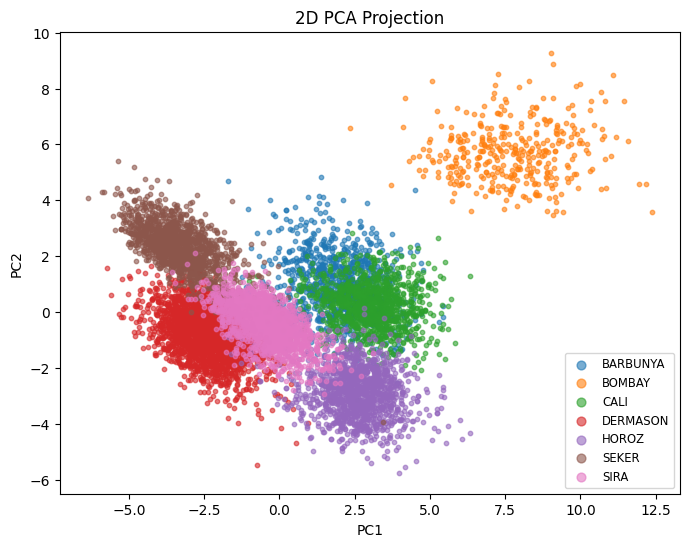

In [5]:
data = prepare_experiment_data(X, y, test_size=0.3, random_state=42)
print("Train:", data.X_train.shape, "Test:", data.X_test.shape)
print("Classes:", data.class_names)
fig = plot_pca_scatter(data.X_train, data.y_train, data.class_names)
fig

## 3. Bayesian / Parametric Classifier

We model each class as a multivariate Gaussian $p(x|w_i) \sim \mathcal{N}(\mu_i, \Sigma_i)$
and classify via Bayes' rule $p(w_i|x) = p(x|w_i)P(w_i)/p(x)$, implemented in log-space
for numerical stability (see `pattern_reg.bayesian_classifier.GaussianBayesClassifier`).

Bayesian accuracy: 0.9081782566111655
              precision    recall  f1-score   support

    BARBUNYA       0.96      0.86      0.91       397
      BOMBAY       1.00      1.00      1.00       157
        CALI       0.92      0.95      0.93       489
    DERMASON       0.94      0.84      0.89      1064
       HOROZ       0.95      0.96      0.96       578
       SEKER       0.93      0.94      0.93       608
        SIRA       0.79      0.91      0.85       791

    accuracy                           0.91      4084
   macro avg       0.93      0.92      0.92      4084
weighted avg       0.91      0.91      0.91      4084



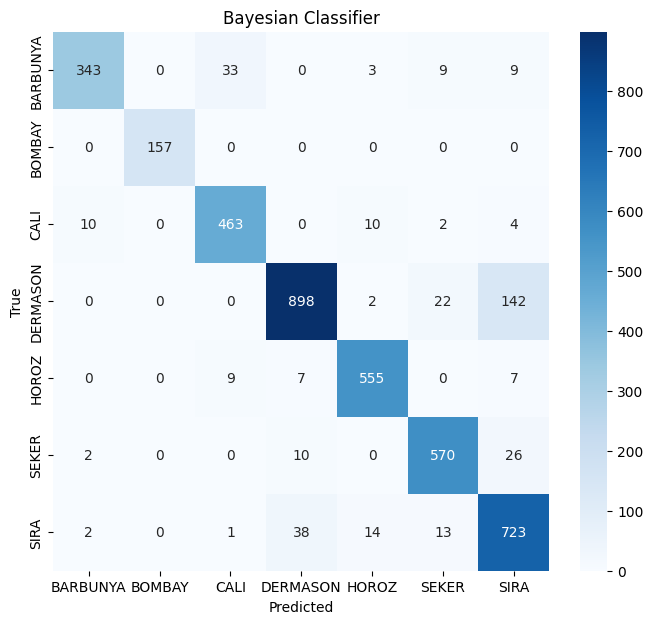

In [6]:
bayes_clf = GaussianBayesClassifier().fit(data.X_train, data.y_train)
bayes_preds = bayes_clf.predict(data.X_test)
bayes_result = evaluate_predictions(data.y_test, bayes_preds, data.class_names)
print("Bayesian accuracy:", bayes_result["accuracy"])
print(bayes_result["classification_report"])
fig = plot_confusion_matrix(bayes_result["confusion_matrix"], data.class_names, "Bayesian Classifier")
fig

## 4. Non-Parametric Classification (k-NN)

We sweep $k \in \{1,3,5,7,9,11,15,21\}$ under two distance metrics (Euclidean, Manhattan).

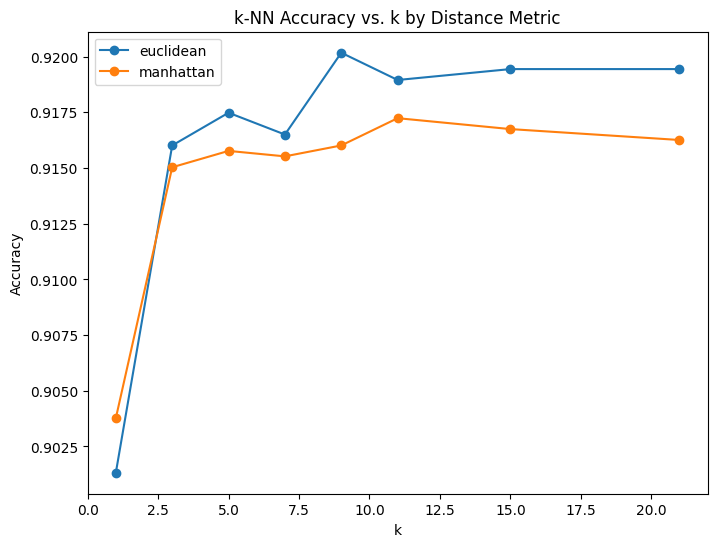

In [7]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
accuracies_by_metric = {}
knn_results = {}
for metric in ("euclidean", "manhattan"):
    accs = []
    knn_results[metric] = {}
    for k in k_values:
        clf = KNNClassifier(k=k, metric=metric).fit(data.X_train, data.y_train)
        preds = clf.predict(data.X_test)
        result = evaluate_predictions(data.y_test, preds, data.class_names)
        knn_results[metric][k] = result
        accs.append(result["accuracy"])
    accuracies_by_metric[metric] = accs

fig = plot_accuracy_vs_k(k_values, accuracies_by_metric)
fig

Best k-NN: metric=euclidean, k=9, accuracy=0.9202
              precision    recall  f1-score   support

    BARBUNYA       0.97      0.89      0.93       397
      BOMBAY       1.00      1.00      1.00       157
        CALI       0.92      0.95      0.94       489
    DERMASON       0.91      0.91      0.91      1064
       HOROZ       0.96      0.96      0.96       578
       SEKER       0.94      0.94      0.94       608
        SIRA       0.85      0.87      0.86       791

    accuracy                           0.92      4084
   macro avg       0.94      0.93      0.93      4084
weighted avg       0.92      0.92      0.92      4084



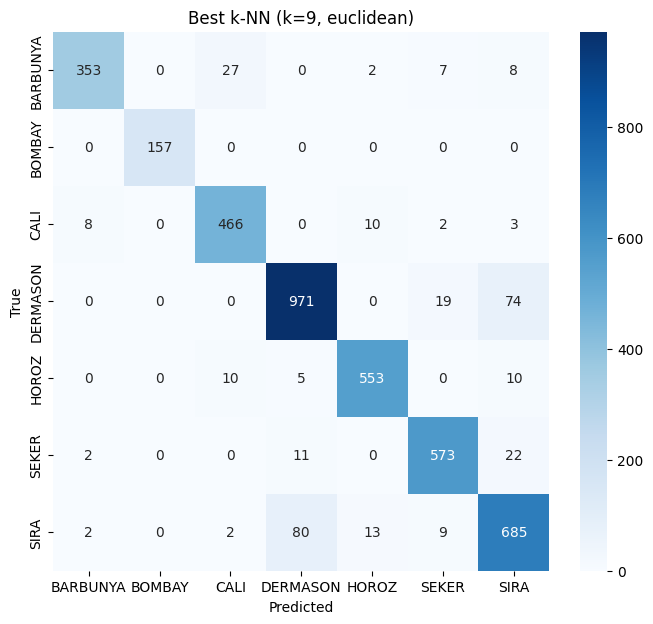

In [8]:
best_metric, best_k, best_acc = None, None, -1
for metric, per_k in knn_results.items():
    for k, result in per_k.items():
        if result["accuracy"] > best_acc:
            best_metric, best_k, best_acc = metric, k, result["accuracy"]
print(f"Best k-NN: metric={best_metric}, k={best_k}, accuracy={best_acc:.4f}")
best_result = knn_results[best_metric][best_k]
print(best_result["classification_report"])
fig = plot_confusion_matrix(best_result["confusion_matrix"], data.class_names, f"Best k-NN (k={best_k}, {best_metric})")
fig

## 5. Comparative Evaluation and Discussion

| Model | Accuracy | Precision (macro) | Recall (macro) | F1 (macro) |
|---|---|---|---|---|
| Gaussian Bayes | 0.9082 | 0.9268 | 0.9238 | 0.9239 |
| Best k-NN (Euclidean, k=9) | 0.9202 | 0.9357 | 0.9314 | 0.9333 |

**Central research question:** How do assumptions about the underlying probability
distribution affect the performance of parametric and non-parametric pattern classifiers?

_(Discussion completed in `report/technical_report.pdf`; this notebook is the
executable companion artifact.)_